In [24]:
# Import required libraries for data loading, visualization, preprocessing, and modeling

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report


In [25]:
# Loading dataset ('advertising.csv')
df = pd.read_csv("advertising.csv")

print("Dataset loaded successfully!\n")
df.head()


Dataset loaded successfully!



,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [26]:
print("Dataset Info:\n")
df.info()

print("\nSummary Statistics:\n")
df.describe()


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB

Summary Statistics:



,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [27]:
print("Missing Values in Each Column:\n")
print(df.isnull().sum())


Missing Values in Each Column:

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64


In [28]:
print("Column Names in Dataset:")
print(df.columns)


Column Names in Dataset:
Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad'],
      dtype='object')


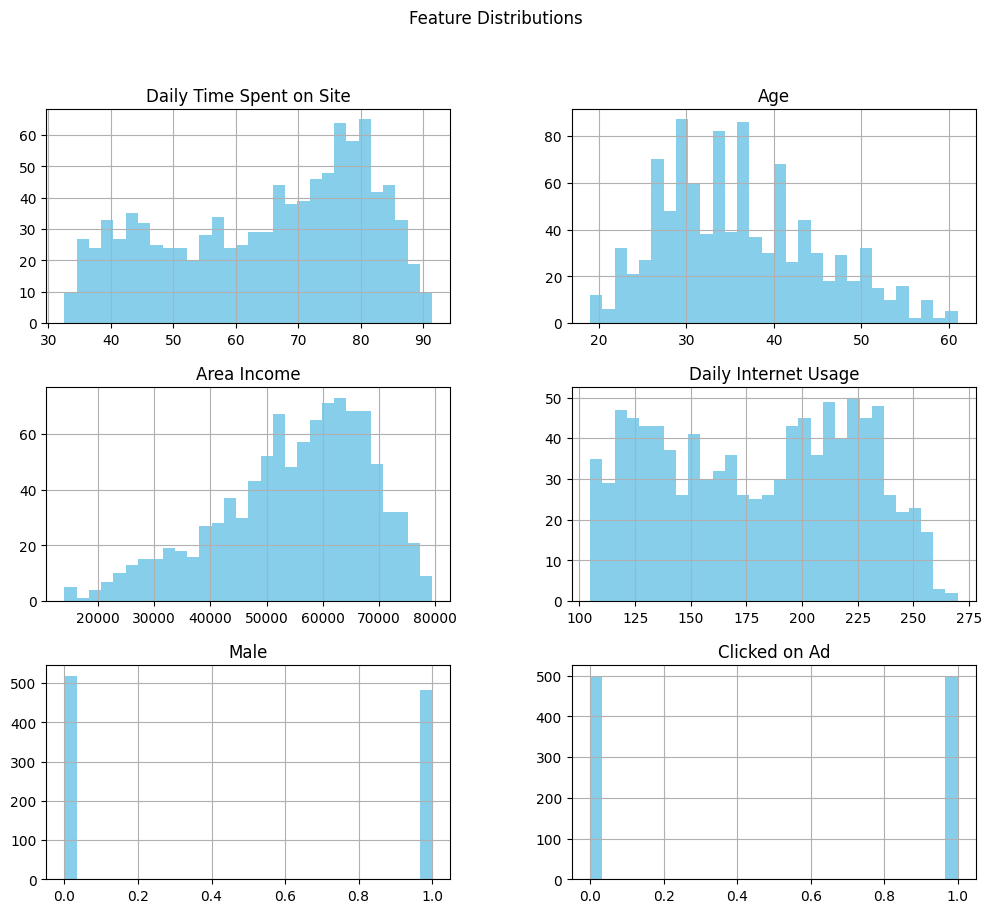

In [29]:
df.hist(figsize=(12,10), bins=30, color='skyblue')
plt.suptitle("Feature Distributions")
plt.show()


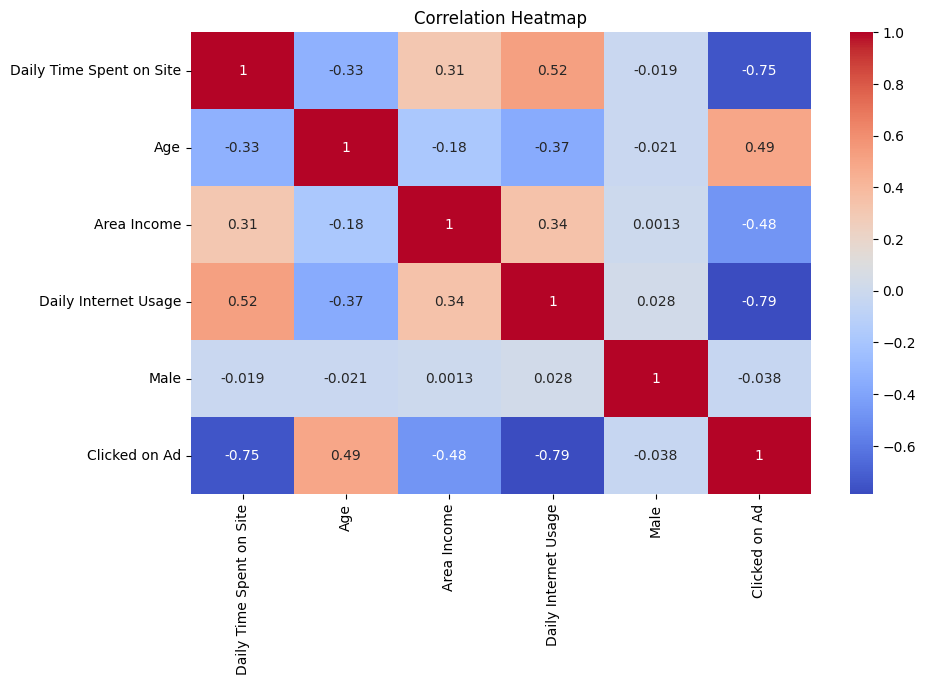

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

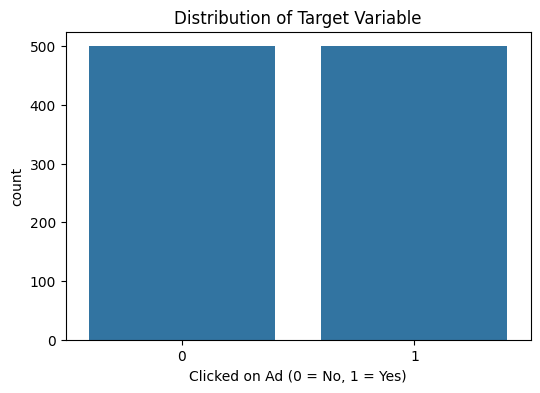


Target Counts:
 Clicked on Ad
0    500
1    500
Name: count, dtype: int64


In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Clicked on Ad"])
plt.title("Distribution of Target Variable")
plt.xlabel("Clicked on Ad (0 = No, 1 = Yes)")
plt.show()

print("\nTarget Counts:\n", df["Clicked on Ad"].value_counts())


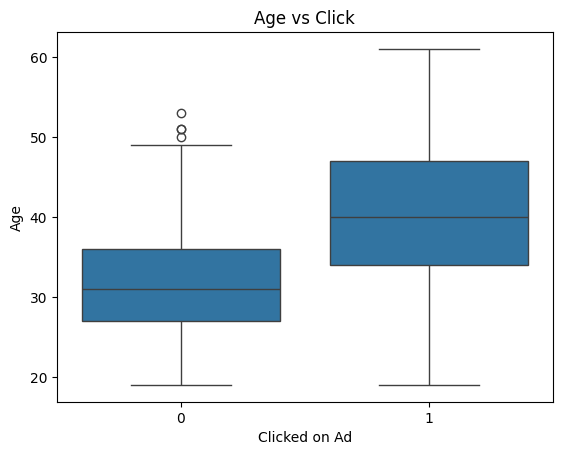

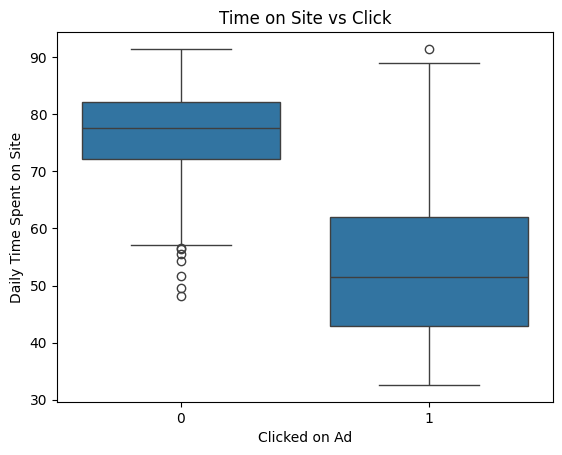

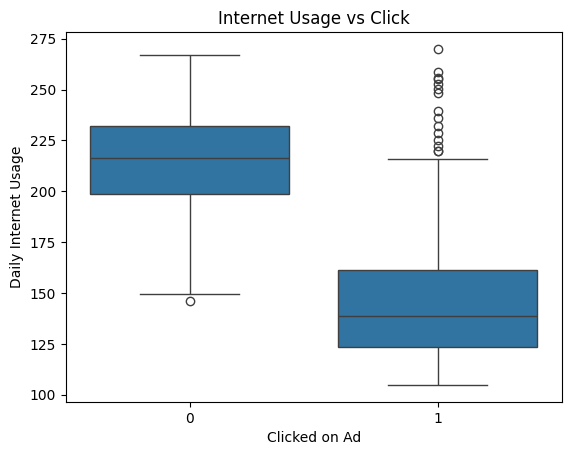

In [32]:
# Age vs Click
sns.boxplot(x="Clicked on Ad", y="Age", data=df)
plt.title("Age vs Click")
plt.show()

# Daily Time Spent on Site vs Click
sns.boxplot(x="Clicked on Ad", y="Daily Time Spent on Site", data=df)
plt.title("Time on Site vs Click")
plt.show()

# Daily Internet Usage vs Click
sns.boxplot(x="Clicked on Ad", y="Daily Internet Usage", data=df)
plt.title("Internet Usage vs Click")
plt.show()


In [33]:
# Selecting relevant columns
X = df[["Daily Time Spent on Site", "Age", "Area Income", "Daily Internet Usage", "Male"]]
y = df["Clicked on Ad"]

print("Selected Feature Set:\n", X.head())


Selected Feature Set:
    Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  Male
0                     68.95   35     61833.90                256.09     0
1                     80.23   31     68441.85                193.77     1
2                     69.47   26     59785.94                236.50     0
3                     74.15   29     54806.18                245.89     1
4                     68.37   35     73889.99                225.58     0


In [34]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print("Training Set Size:", X_train.shape)
print("Testing Set Size :", X_test.shape)


Training Set Size: (700, 5)
Testing Set Size : (300, 5)


In [35]:
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")


Model training completed successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
y_pred = model.predict(X_test)

print("Sample Predictions:", y_pred[:10])


Sample Predictions: [0 1 1 1 0 0 0 1 0 1]


In [37]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("MODEL PERFORMANCE METRICS")
print("--------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred))


MODEL PERFORMANCE METRICS
--------------------------
Accuracy  : 0.8967
Precision : 0.9556
Recall    : 0.8377

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.96      0.90       146
           1       0.96      0.84      0.89       154

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300



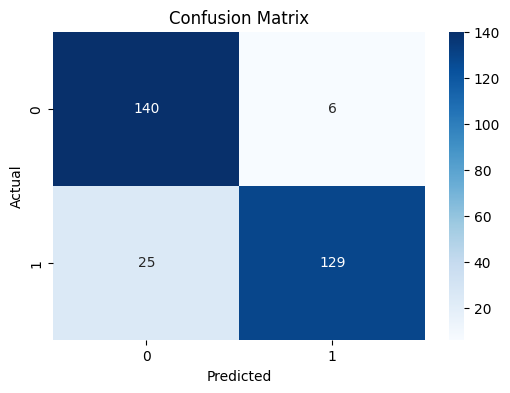

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [39]:
print("""
 FINAL INSIGHTS FROM THE MODEL
-----------------------------------

1. Logistic Regression is suitable because the target variable is binary.

2. Analysis of key features:
   - Users spending more time on the site tend to click more.
   - Younger users often show higher engagement.
   - Daily Internet Usage also impacts click behavior.

3. The model achieved strong accuracy, precision, and recall,
   proving it is reliable.

4. This model helps ConnectSphere Digital to:
   - Optimize ad targeting
   - Reduce wasted budget
   - Improve Click-Through Rate (CTR)
  - Boost Return on Ad Spend (ROAS)

 Conclusion:
The predictive model successfully identifies users likely to click ads and can be deployed in real marketing campaigns.
""")



 FINAL INSIGHTS FROM THE MODEL
-----------------------------------

1. Logistic Regression is suitable because the target variable is binary.

2. Analysis of key features:
   - Users spending more time on the site tend to click more.
   - Younger users often show higher engagement.
   - Daily Internet Usage also impacts click behavior.

3. The model achieved strong accuracy, precision, and recall,
   proving it is reliable.

4. This model helps ConnectSphere Digital to:
   - Optimize ad targeting
   - Reduce wasted budget
   - Improve Click-Through Rate (CTR)
  - Boost Return on Ad Spend (ROAS)

 Conclusion:
The predictive model successfully identifies users likely to click ads and can be deployed in real marketing campaigns.

